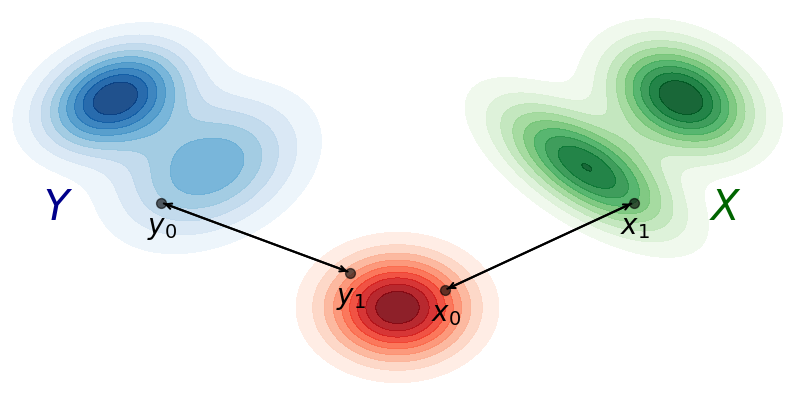

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Set up the grid (higher resolution)
x, y = np.linspace(-8.2, 8.2, 400), np.linspace(-2.5, 8.5, 400)
X, Y = np.meshgrid(x, y)

# Define Gaussian components (shifted for proper spacing)
mu_left1 = [-4, 4]
sigma_left1 = [[1.6, 1.0], [0.5, 1.7]]
Z_left1 = multivariate_normal.pdf(np.dstack((X, Y)), mean=mu_left1, cov=sigma_left1)

mu_left2 = [-6, 6]
sigma_left2 = [[1.0, 0.3], [0.3, 1.0]]
Z_left2 = multivariate_normal.pdf(np.dstack((X, Y)), mean=mu_left2, cov=sigma_left2)

# Combine the two Gaussian components to create a mixture
Z_left = Z_left1 + Z_left2

mu_center = [0, 0]
sigma_center = [[1, 0], [0, 1]]
Z_center = multivariate_normal.pdf(np.dstack((X, Y)), mean=mu_center, cov=sigma_center)

mu_right1 = [4, 4]
sigma_right1 = [[1.5, -1.0], [-1.0, 1.5]]
Z_right1 = multivariate_normal.pdf(np.dstack((X, Y)), mean=mu_right1, cov=sigma_right1)

mu_right2 = [6, 6]
sigma_right2 = [[1.0, -0.3], [-0.3, 1.1]]
Z_right2 = multivariate_normal.pdf(np.dstack((X, Y)), mean=mu_right2, cov=sigma_right2)

# Combine the two Gaussian components to create a mixture
Z_right = Z_right1 + Z_right2

# Normalize for visibility (without washing out previous layers)
Z_left /= Z_left.max()
Z_center /= Z_center.max()
Z_right /= Z_right.max()

# Create the plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_facecolor("white")  # Pure white background

# Plot contour maps with **stronger contrast**
contour_levels = np.linspace(0.1, 1.0, 10)  # Adjust contour strength

ax.contourf(X, Y, Z_left, levels=contour_levels, cmap="Blues", alpha=0.9)
ax.contourf(X, Y, Z_center, levels=contour_levels, cmap="Reds", alpha=0.9)
ax.contourf(X, Y, Z_right, levels=contour_levels, cmap="Greens", alpha=0.9)

# Define key points
points = {
    r"$y_0$": [-5, 3], 
    r"$y_1$": [-1, 1],
    r"$x_0$": [1, 0.5],
    r"$x_1$": [5, 3]
}

# Plot key points with **formatted labels**
for label, (px, py) in points.items():
    ax.scatter(px, py, color="black", s=50, zorder=3, alpha=0.6)
    ax.text(px - 0.3, py - 0.9, label, fontsize=20, color="black", fontweight="bold")

# Add **clear arrows** (not dashed lines)
arrow_style = dict(arrowstyle="->", color="black", linewidth=1.5)

# Two-way arrows between Y1 ↔ Y0 and X0 ↔ X1
ax.annotate("", xy=points[r"$y_0$"], xytext=points[r"$y_1$"], arrowprops=arrow_style)
ax.annotate("", xy=points[r"$y_1$"], xytext=points[r"$y_0$"], arrowprops=arrow_style)
ax.annotate("", xy=points[r"$x_1$"], xytext=points[r"$x_0$"], arrowprops=arrow_style)
ax.annotate("", xy=points[r"$x_0$"], xytext=points[r"$x_1$"], arrowprops=arrow_style)
# add a big blue Y and a big green X
ax.text(-7.5, 2.5, r"$Y$", fontsize=30, color="darkblue", fontweight="bold", fontname="Arial")
ax.text(6.6, 2.5, r"$X$", fontsize=30, color="darkgreen", fontweight="bold", fontname="Arial")

# Remove axes for a **clean look**
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)

plt.show()


c:\Users\20236095\symmetricflow\.venv-dev\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Found 4995 images and 4995 masks in the val dataset


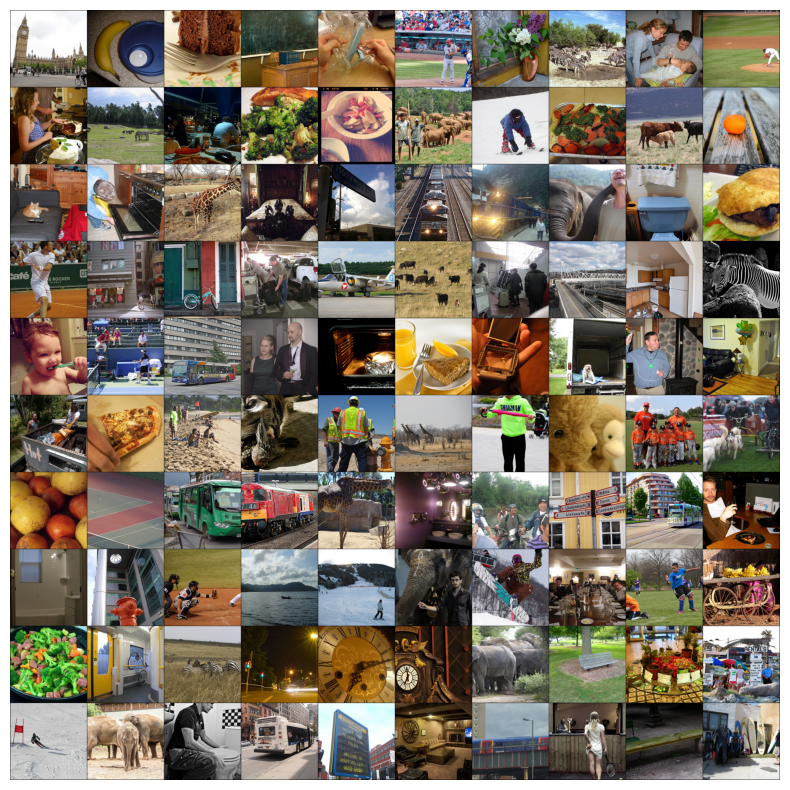

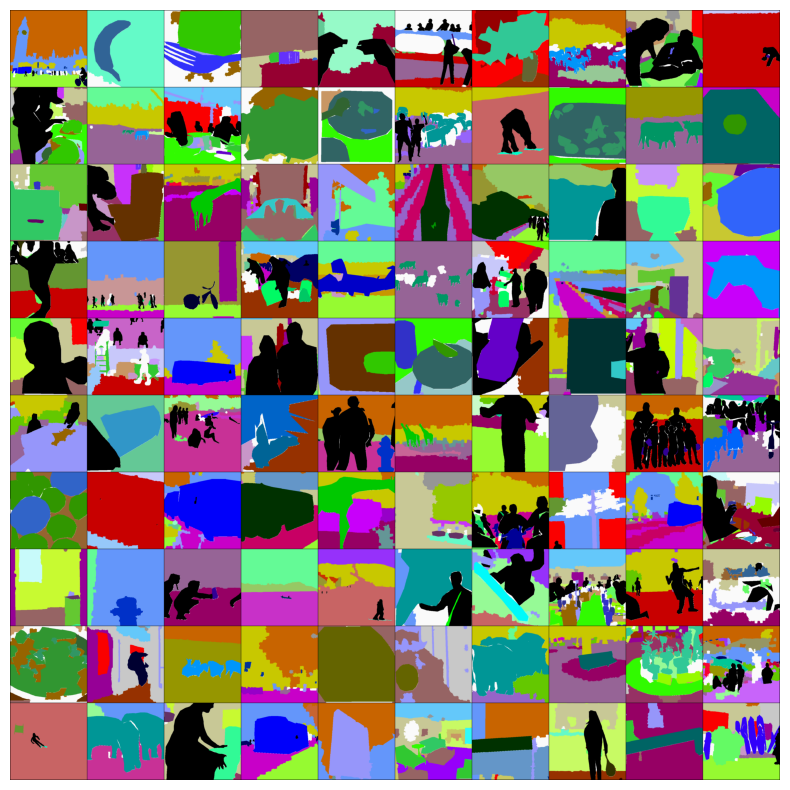

In [1]:
from data.Dataloaders import cocostuff_dataloader
import torch
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

_,_,dataloader = cocostuff_dataloader(batch_size=100, num_workers=0, mode='val', input_shape=448)
for i, (images, targets) in enumerate(dataloader):
    #plot the 2 grids
    images = images*0.5 + 0.5
    images = images.clamp(0, 1)
    images = make_grid(images, nrow=10, padding=2).permute(1, 2, 0).numpy()
    plt.figure(figsize=(10, 10))
    plt.imshow(images)
    plt.axis('off')
    plt.show()
    #plot the 2 grids
    targets = targets*0.5 + 0.5
    targets = targets.clamp(0, 1)
    targets = make_grid(targets, nrow=10, padding=2).permute(1, 2, 0).numpy()
    plt.figure(figsize=(10, 10))
    plt.imshow(targets)
    plt.axis('off')
    plt.show()
    break

c:\Users\20236095\symmetricflow\.venv-dev\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


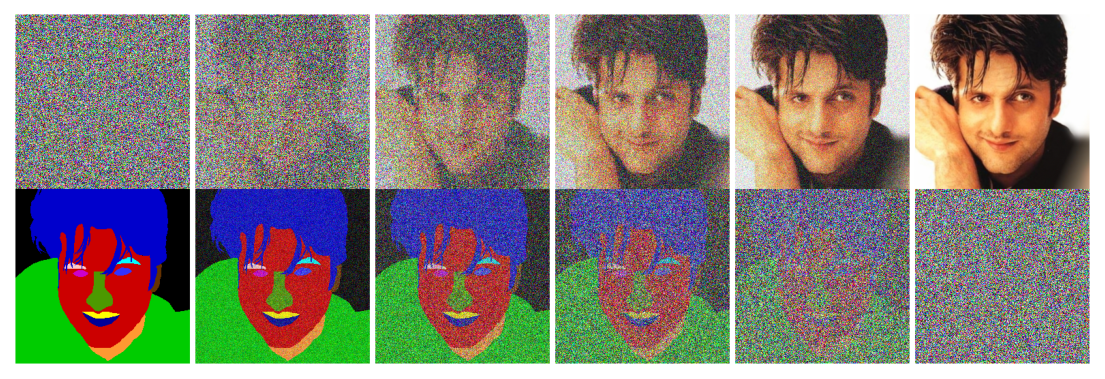

In [2]:
from data.Dataloaders import celeb_hq_masked_dataloader
import torch
from torchvision.utils import make_grid

_,_,dataloader = celeb_hq_masked_dataloader(batch_size=1, num_workers=0)
for i, (img, mask) in enumerate(dataloader):
    # normalize them back to 0-1

    for i in range(0,6):
        noisy_img = img*(i/5) + (1-i/5)*torch.randn_like(img)
        if i == 0:
            images = noisy_img.clone()
        else:
            images = torch.cat((images, noisy_img), dim=0)

    for i in range(5,-1,-1):
        noisy_mask = mask*(i/5) + (1-i/5)*torch.randn_like(mask)
        if i == 5:
            masks = noisy_mask.clone()
        else:
            masks = torch.cat((masks, noisy_mask), dim=0)

    # normalize them back to 0-1
    images = (images + 1) / 2
    masks = (masks + 1) / 2
    # clamp them to 0-1
    images = torch.clamp(images, 0, 1)
    masks = torch.clamp(masks, 0, 1)

    # combine images and masks
    combined = torch.cat((images, masks), dim=2)
    # make a grid
    grid = make_grid(combined, nrow=6, padding=8, pad_value=1)
    # convert to numpy
    grid = grid.permute(1,2,0).cpu().numpy()
    # plot
    plt.figure(figsize=(14, 8))
    plt.imshow(grid)
    plt.axis('off')
    plt.show()
    break